# Snow Ski Report and Forecast

## January 2026
## Extracts data from OpenSnow snow reporting site through the paywall and displays it visually
## Check that POW report BRO
#### If this is the first ever time running this notebook, the packages below will install first
#### Just click run and scroll down to see the map
### NEXT STEPS: Make It a Shareable Web App, Eventually this should become: Streamlit app, Or small Dash app

In [11]:
#install necessary packages before trying to import

#(you can also do this in your venv in terminal)
!pip install pandas requests beautifulsoup4 folium numpy
#install dependencies to be able to extract the data from the OpenSnow site
!pip install selenium webdriver-manager
#for compatibility
!pip install --upgrade typing_extensions

### Import all the packages you installed

In [12]:
import sys
print(sys.version)
import pandas as pd
import requests
from bs4 import BeautifulSoup
import requests
from datetime import date
import os
import folium
from folium import FeatureGroup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
print("All imports OK")

3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
All imports OK


### Extract the data from OpenSnow site both Epic and Ikon pass resort data

In [13]:
import requests
import pandas as pd
from datetime import datetime

# Save path for CSV
csv_path = "ikon_epic_daily_snow_totals_full.csv"

# API info
API_KEY = "60600760edf827a75df71f712b71e3f3"  # same as before

# Base JSON URLs for Ikon and Epic
RESORT_SOURCES = {
    "Ikon": "https://opensnow.com/mtn/compare/season-passes/ikonpass/forecasts/snow-summary",
    "Epic": "https://opensnow.com/mtn/compare/season-passes/epicpass/forecasts/snow-summary"
}

# Extraction helper
def extract_summary(summary, label):
    for s in summary:
        if s.get("display_at_local_label") == label:
            return s.get("precip_snow")
    return None

# Container for all records
all_records = []
forecast_timestamp = None

for source_name, JSON_BASE in RESORT_SOURCES.items():
    print(f"Fetching {source_name} resorts...")
    limit, skip = 20, 0

    while True:
        url = (
            f"{JSON_BASE}?v=1&api_key={API_KEY}"
            f"&days=15&dir=asc&limit={limit}&skip={skip}"
            f"&sort=alpha&units=imperial"
        )

        data = requests.get(url).json()
        locations = data.get("locations", [])
        if not locations:
            break

        # Capture timestamp from first resort if not already set
        if forecast_timestamp is None:
            forecast_timestamp = locations[0].get("forecast_updated_at")

        for r in locations:
            history_daily = r.get("history_snow_daily", [])
            history_summary = r.get("history_snow_summary", [])
            forecast_summary = r.get("forecast_snow_summary", [])

            last_24 = history_daily[-1]["precip_snow"] if history_daily else None
            coords = r.get("coordinates", {}).get("point", [None, None])
            longitude, latitude = coords

            all_records.append({
                "resort_name": r.get("name"),
                "source": source_name,  # Ikon or Epic
                "location": f"{r.get('state_name','')}, {r.get('country_name','')}".strip(", "),
                "last_24hr_snow": last_24,
                "prev_1_5_days": extract_summary(history_summary, "Prev 1-5 Days"),
                "prev_6_10_days": extract_summary(history_summary, "Prev 6-10 Days"),
                "prev_11_15_days": extract_summary(history_summary, "Prev 11-15 Days"),
                "next_1_5_days": extract_summary(forecast_summary, "Next 1-5 Days"),
                "next_6_10_days": extract_summary(forecast_summary, "Next 6-10 Days"),
                "next_11_15_days": extract_summary(forecast_summary, "Next 11-15 Days"),
                "latitude": latitude,
                "longitude": longitude,
                "forecast_updated_at": r.get("forecast_updated_at") #snow collection measuring/reporting time!!!
            })

        skip += limit

# Convert to DataFrame
df_all = pd.DataFrame(all_records)

#Get timestamp range to display in title (range of all of the resorts' snow reporting times):::
# Convert to datetime first
df_all["forecast_updated_at"] = pd.to_datetime(df_all["forecast_updated_at"])

earliest = df_all["forecast_updated_at"].min()
latest = df_all["forecast_updated_at"].max()

formatted_timestamp = (
    f"{earliest.strftime('%b %d, %H:%M')}–"
    f"{latest.strftime('%H:%M UTC')}"
)

# Display shape
print("Combined DataFrame shape:", df_all.shape)

# Optional: save to CSV
df_all.to_csv(csv_path, index=False)

# Display first few rows
df_all.head()


Fetching Ikon resorts...
Fetching Epic resorts...
Combined DataFrame shape: (201, 13)


,resort_name,source,location,last_24hr_snow,prev_1_5_days,prev_6_10_days,prev_11_15_days,next_1_5_days,next_6_10_days,next_11_15_days,latitude,longitude,forecast_updated_at
0,3 Zinnen (3 Peaks) Dolomites,Ikon,"Bolzano, Italy",2.0,12,2,0,0,1,1,46.7127,12.3641,2026-02-22 14:12:21+00:00
1,Alpe di Siusi,Ikon,"Bolzano, Italy",2.0,11,2,0,0,1,0,46.5312,11.6258,2026-02-22 15:00:35+00:00
2,Alpental at Snoqualmie,Ikon,"Washington, United States",1.0,7,6,0,24,6,6,47.4361,-121.4354,2026-02-22 14:36:37+00:00
3,Alta,Ikon,"Utah, United States",0.0,52,4,12,10,7,4,40.5784,-111.6328,2026-02-22 14:00:43+00:00
4,Alyeska,Ikon,"Alaska, United States",NaN,2,4,6,1,5,13,60.9604,-149.0908,2026-02-22 14:48:49+00:00


In [14]:
#showing where to save the data
csv_path = "ikon_daily_snow_totals_full.csv"

#opensnow URL for Ikon mountains 
#cant directly access this in your search bar but can pull info from it (behind the paywall)
JSON_BASE = "https://opensnow.com/mtn/compare/season-passes/ikonbase/forecasts/snow-summary"
API_KEY = "60600760edf827a75df71f712b71e3f3"

records = []
limit, skip = 20, 0

#method for data extraction
#can add to this to collect more information
def extract_summary(summary, label):
    for s in summary:
        if s.get("display_at_local_label") == label:
            return s.get("precip_snow")
    return None

#zero out the time stamp to make sure we're gettin the correct date of the report
forecast_timestamp = None

while True:
    url = (
        f"{JSON_BASE}?v=1&api_key={API_KEY}"
        f"&days=15&dir=asc&limit={limit}&skip={skip}"
        f"&sort=alpha&units=imperial"
    )

    data = requests.get(url).json()
    # Capture forecast timestamp from first resort
    if forecast_timestamp is None:
        locations = data.get("locations", [])
        if locations:
            forecast_timestamp = locations[0].get("forecast_updated_at")
    #print(data.keys()) #debug
    #print(data) # debug
    resorts = data.get("locations", [])
    if not resorts:
        break
    
    for r in resorts:
        history_daily = r.get("history_snow_daily", [])
        history_summary = r.get("history_snow_summary", [])
        forecast_summary = r.get("forecast_snow_summary", [])
    
        # last 24hr snowfall
        last_24 = history_daily[-1]["precip_snow"] if history_daily else None
    
        # coordinates
        coords = r.get("coordinates", {}).get("point", [None, None])
        longitude = coords[0]
        latitude = coords[1]
    
        records.append({
            "resort_name": r.get("name"),
            "location": f"{r.get('state_name','')}, {r.get('country_name','')}".strip(", "),
            "last_24hr_snow": last_24,
            "prev_1_5_days": extract_summary(history_summary, "Prev 1-5 Days"),
            "prev_6_10_days": extract_summary(history_summary, "Prev 6-10 Days"),
            "prev_11_15_days": extract_summary(history_summary, "Prev 11-15 Days"),
            "next_1_5_days": extract_summary(forecast_summary, "Next 1-5 Days"),
            "next_6_10_days": extract_summary(forecast_summary, "Next 6-10 Days"),
            "next_11_15_days": extract_summary(forecast_summary, "Next 11-15 Days"),
            "latitude": latitude, #for mapping 
            "longitude": longitude,
            "forecast_updated_at": r.get("forecast_updated_at") #collect all of the resorts' snow reporting times
        })


    skip += limit

df_new = pd.DataFrame(records)

#Get timestamp range to display in title (range of all of the resorts' snow reporting times):::
# Convert to datetime first
df_new["forecast_updated_at"] = pd.to_datetime(df_new["forecast_updated_at"])

earliest = df_new["forecast_updated_at"].min()
latest = df_new["forecast_updated_at"].max()

formatted_timestamp = (
    f"{earliest.strftime('%b %d, %H:%M')}–"
    f"{latest.strftime('%H:%M UTC')}"
)

In [15]:
#check to make sure we have the correct data now

display(df_new.shape)
display(df_new.head(5))

#save the data to the csv defined above csv
df_new.to_csv(csv_path, index=False)
print(f"Saved {len(df_new)} rows to {csv_path}")

(108, 12)

,resort_name,location,last_24hr_snow,prev_1_5_days,prev_6_10_days,prev_11_15_days,next_1_5_days,next_6_10_days,next_11_15_days,latitude,longitude,forecast_updated_at
0,3 Zinnen (3 Peaks) Dolomites,"Bolzano, Italy",2.0,12,2,0,0,1,1,46.7127,12.3641,2026-02-22 14:12:21+00:00
1,Alpe di Siusi,"Bolzano, Italy",2.0,11,2,0,0,1,0,46.5312,11.6258,2026-02-22 15:00:35+00:00
2,Alpental at Snoqualmie,"Washington, United States",1.0,7,6,0,24,6,6,47.4361,-121.4354,2026-02-22 14:36:37+00:00
3,Alyeska,"Alaska, United States",NaN,2,4,6,1,5,13,60.9604,-149.0908,2026-02-22 14:48:49+00:00
4,Appi Kogen,"Iwate, Japan",0.0,7,2,8,4,1,11,39.9882,140.9620,2026-02-22 15:36:10+00:00


Saved 108 rows to ikon_daily_snow_totals_full.csv


In [16]:
#define some of the columns in this df
snow_cols = [
    "last_24hr_snow",
    "prev_1_5_days",
    "prev_6_10_days",
    "prev_11_15_days",
    "next_1_5_days",
    "next_6_10_days",
    "next_11_15_days",
]

#deal with some of the tricky values
df_all[snow_cols] = df_all[snow_cols].apply(pd.to_numeric, errors="coerce")

### Past 24 hour snow all resorts

Summary of last 24hr snowfall:


count    52.000000
mean      3.442308
std       3.438042
min       1.000000
25%       1.000000
50%       1.500000
75%       6.250000
max      15.000000
Name: last_24hr_snow, dtype: float64

,resort_name,location,last_24hr_snow
189,Stuben am Arlberg,"Vorarlberg, Austria",15.0
146,Hintertux,"Tirol, Austria",12.0
164,Montafon,"Vorarlberg, Austria",10.0
50,Mittersill,"Tirol, Austria",9.0
184,Sölden,"Tirol, Austria",8.0
129,Disentis,"Graubünden, Switzerland",8.0
39,Kirchberg,"Tirol, Austria",8.0
29,Cypress Mountain,"British Columbia, Canada",7.0
161,Mayrhofen,"Tirol, Austria",7.0
117,Andermatt,"Uri, Switzerland",7.0


/var/folders/yq/blfjj9vn7vvf5tt08v98q_qr0000gn/T/ipykernel_22980/397997603.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


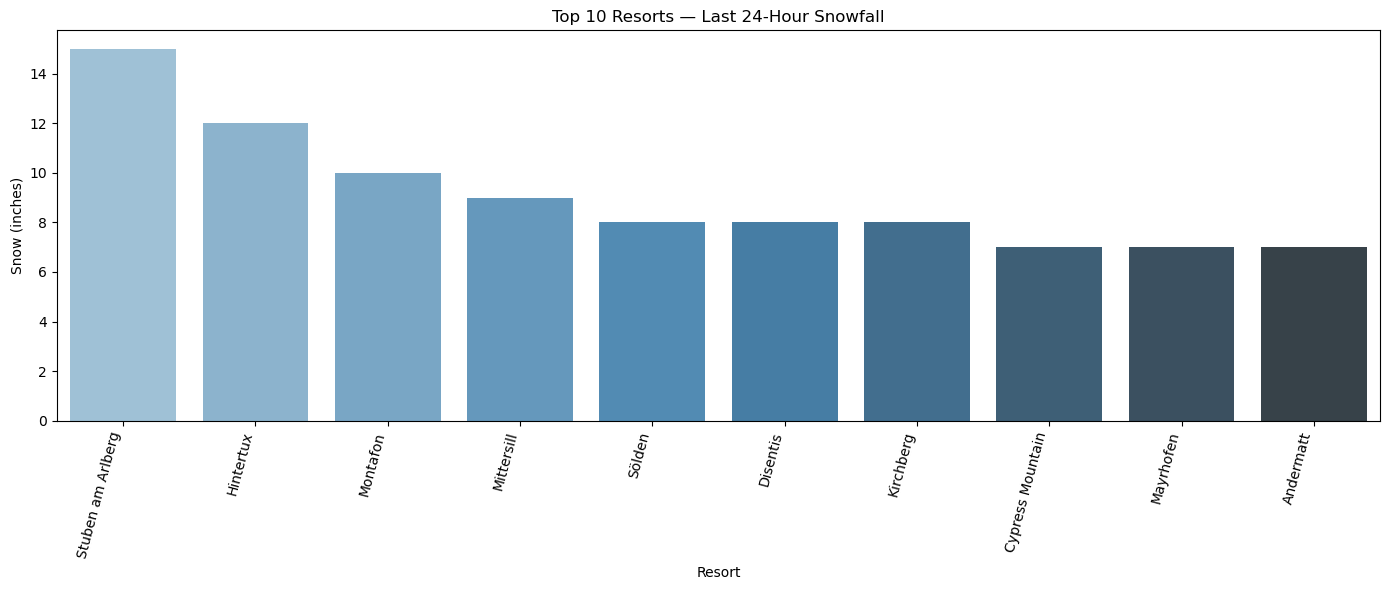

In [17]:
# Work on a copy of the data
df_24 = df_all.copy()

# Ensure numeric snowfall
df_24["last_24hr_snow"] = pd.to_numeric(
    df_24["last_24hr_snow"], errors="coerce"
)

# Drop missing or zero snowfall (optional: comment out zero filter if desired)
df_24 = df_24.dropna(subset=["last_24hr_snow"])
df_24 = df_24[df_24["last_24hr_snow"] > 0]

print("Summary of last 24hr snowfall:")
display(df_24["last_24hr_snow"].describe())

# Show top resorts table
top_n = 10
df_top = df_24.sort_values(
    "last_24hr_snow", ascending=False
).head(top_n)

display(
    df_top[
        ["resort_name", "location", "last_24hr_snow"]
    ]
)

# Plot
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_top,
    x="resort_name",
    y="last_24hr_snow",
    palette="Blues_d"
)

plt.xticks(rotation=75, ha="right")
plt.title("Top 10 Resorts — Last 24-Hour Snowfall")
plt.ylabel("Snow (inches)")
plt.xlabel("Resort")
plt.tight_layout()
plt.show()


In [18]:
#idea for a wieghted score here (as a layer of the map)
#'GPT "powder score"
'''
df_ne["powder_score"] = (
    0.5 * df_ne["next_1_5_days"] +
    0.3 * df_ne["next_6_10_days"] +
    0.2 * df_ne["next_11_15_days"]
)
'''

'\ndf_ne["powder_score"] = (\n    0.5 * df_ne["next_1_5_days"] +\n    0.3 * df_ne["next_6_10_days"] +\n    0.2 * df_ne["next_11_15_days"]\n)\n'

### Cycling Forecast map for the entire us

In [19]:
### USA lower 48 bounding box (adjustable)
# im just zooming in on the lower 48 but you can zoom where ever
lon_min, lon_max = -130, -50
lat_min, lat_max = 25, 60

# Filter resorts
df_usa = df_all[
    (df_all["longitude"] >= lon_min) &
    (df_all["longitude"] <= lon_max) &
    (df_all["latitude"] >= lat_min) &
    (df_all["latitude"] <= lat_max)
].dropna(subset=["next_1_5_days","next_6_10_days","next_11_15_days"])

# NOAA‑style color mapping function
def noaa_color(snow):
    if snow is None or snow == 0:
        return "#ffffff"  # white for zero
    # Define color buckets
    if snow <= 3:
        return "#a6cee3"  # light cyan
    elif snow <= 6:
        return "#1f78b4"  # medium blue
    elif snow <= 9:
        return "#33a02c"  # green
    elif snow <= 12:
        return "#ffdd57"  # yellow
    elif snow <= 15:
        return "#fd8d3c"  # orange
    else:
        return "#e31a1c"  # red

# Initialize map
m = folium.Map( ##must DEFINE m here or eveyrthing will silently fail!!
    location=[42, -73],
    zoom_start=6,
    tiles=None  # Start blank so we can add multiple layers
)

# Base topo
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Elevation/World_Hillshade/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri, USGS",
    name="Esri USGS Topo",
    overlay=False,
    control=True
).add_to(m)

# Roads overlay
folium.TileLayer(
    tiles="CartoDB positron",
    attr="Map tiles by CartoDB, © OpenStreetMap contributors",
    name="Roads",
    overlay=True,
    control=False,
    opacity=0.7  # semi-transparent so topo shows through
).add_to(m)


#Add real time stamp from the data
title_html = f"""
<div style="
position: fixed;
top: 10px; left: 50%;
transform: translateX(-50%);
z-index: 9999;
background-color: white;
padding: 8px 15px;
border: 2px solid grey;
font-size:16px;
font-weight:bold;"<small>Forecast Updated: {formatted_timestamp}</small>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Forecast periods & labels
periods = ["last_24hr_snow","next_1_5_days","next_6_10_days","next_11_15_days"]
labels = ["Last 24 Hours","Next 1–5 Days","Next 6–10 Days","Next 11–15 Days"]

for col, label in zip(periods, labels):
    fg = FeatureGroup(name=label)
    for _, row in df_usa.iterrows():
        snow = row[col]
        # Scale circle size (min 5 — max 15)
        radius = np.interp(snow if snow else 0, [0,18],[5,15])
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=radius,
            color="black",
            fill=True,
            fill_color=noaa_color(snow),
            fill_opacity=0.8,
            popup=f"{row['resort_name']}<br>{label}: {snow} in",  # existing popup
            tooltip=f"{row['resort_name']}<br>{label}:  — {snow} in"           # hover text
        ).add_to(fg)
    fg.add_to(m)

# Layer control
folium.LayerControl().add_to(m)

# Custom NOAA‑style legend
#different color band and circle size for each snow amount
legend_html = """
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 180px; height: 230px;
background-color: white; z-index: 9999;
font-size:14px; padding: 10px; border:2px solid grey;">
<b>Snow (inches)</b><br>
<i style='background:#ffffff;width:20px;height:20px;display:inline-block'></i>&nbsp;0<br> 
<i style='background:#a6cee3;width:20px;height:20px;display:inline-block'></i>&nbsp;1–3<br>
<i style='background:#1f78b4;width:20px;height:20px;display:inline-block'></i>&nbsp;4–6<br>
<i style='background:#33a02c;width:20px;height:20px;display:inline-block'></i>&nbsp;7–9<br>
<i style='background:#ffdd57;width:20px;height:20px;display:inline-block'></i>&nbsp;10–12<br>
<i style='background:#fd8d3c;width:20px;height:20px;display:inline-block'></i>&nbsp;13–15<br>
<i style='background:#e31a1c;width:20px;height:20px;display:inline-block'></i>&nbsp;16–18+
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m